# Setup libraries 

In [648]:
import Pkg
Pkg.add([
        "CSV",
        "DataFrames",
        "Glob",
        "Makie",
        "CairoMakie",
        "Distributions",
        "HypothesisTests",
        "CategoricalArrays",
        "StatsBase"
        ])

   Resolving package versions...
   Installed StatsBase ─ v0.34.8
    Updating `~/.julia/environments/v1.11/Project.toml`
  [2913bbd2] + StatsBase v0.34.8
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [2913bbd2] ↑ StatsBase v0.34.6 ⇒ v0.34.8
Precompiling project...
   1306.8 ms  ✓ StatsBase
  1 dependency successfully precompiled in 3 seconds. 362 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version. Otherwise, loading dependents of this package may trigger further precompilation to work with the unexpected version.


In [649]:
import CSV
using DataFrames
using CategoricalArrays
using Glob
using Makie, CairoMakie
using Statistics, Distributions, HypothesisTests, StatsBase
using ColorSchemes: tab10
using Colors

In [639]:
lerp(a::Color, b::Color, val::AbstractFloat) = (a .+ (val * (b .- a)))
th = Theme(
    colormap = :tab10,
    palette = Attributes(
        color = tab10,
        patchcolor = map(c -> lerp(RGB(1,1,1), c, 0.8f0), tab10)
    ),
    Axis = (
        colorrange = (1,10),
    ),
    Hist = (
        color = tab10[1],
    ),
)
set_theme!(merge(th))

# Import data

## Merge data from different files

In [924]:
colset = [
    "match_id",
    "ElapsedTime",
    "SetNo",
    # "P1GamesWon",
    # "P2GamesWon",
    "SetWinner",
    "GameNo",
    "GameWinner",
    "PointNumber",
    "PointWinner",
    "PointServer",
    # "Speed_KMH",
    "P1Score",
    "P2Score",
    "P1PointsWon",
    "P2PointsWon",
    # "P1Ace",
    # "P2Ace",
    # "P1Winner",
    # "P2Winner",
    # "P1DoubleFault",
    # "P2DoubleFault",
    # "P1UnfErr",
    # "P2UnfErr",
    "P1BreakPoint",
    "P2BreakPoint",
    "P1BreakPointWon",
    "P2BreakPointWon",
    # "P1SecondSrvIn",
    # "P2SecondSrvIn",
    # "P1SecondSrvWon",
    # "P2SecondSrvWon",
    # "P1ForcedError",
    # "P2ForcedError"
];

In [925]:
dfs = Dict(basename(f) => CSV.read(f, DataFrame) for f in glob("*points.csv", "tennis-data"))
tournaments = keys(dfs) |> collect |> sort
sorted_dfs = [dfs[t] for t in tournaments]
common_cols = intersect([names(df) for df in sorted_dfs]...);

In [926]:
all_matches = vcat([select!(df, colset) for df in sorted_dfs]...);

## Remove entire matches when necessary data are missing

In [974]:
df = all_matches
kept = []
required_cols = [
    :P1BreakPoint,
    :P2BreakPoint,
    :PointWinner,
    :PointNumber,
]
set_grps = groupby(df, [:match_id])
dfg = [grp for grp in set_grps if !any(ismissing.(Matrix(grp[:, required_cols])))];
df = vcat(dfg...)

println("Removed missing matches: $(length(set_grps) - length(dfg))")

Removed missing matches: 2087


## Add year, tournament, and match number

In [975]:
# add tournament and year columns
function from_matchid(mid)
    (year, tmnt) = match(r"(\d{4})-([a-z]+)", mid)
    year = parse(Int, year)
    permutedims([year, tmnt])
end

yr_tmnt = vcat(from_matchid.(df.match_id)...)
insertcols!(df, 2, :Year => yr_tmnt[:,1], :Tmnt => yr_tmnt[:,2]);

In [976]:
insertcols!(df, 4, :MatchNum => missing)
for gdf in groupby(df, :Year)
    gdf[!,:MatchNum] = groupindices(groupby(gdf, :match_id))
end

## Add player ids

In [977]:
mdf = vcat([CSV.read(f, DataFrame) for f in glob("*matches.csv", "clean-data")]...);

In [978]:
leftjoin!(df, mdf[:,[:match_id, :player1id, :player2id]], on = :match_id);

## Add BreakPoint, Tiebreaker and ServerWon columns

### BreakPoint column

In [979]:
df[:,:BreakPoint] = BitVector((df.P1BreakPoint) .+ (df.P2BreakPoint));

### Tiebreaker column

In [980]:
tb_games_ids = [
    Vector(grp[1, [:match_id, :SetNo, :GameNo]]) for grp in 
        groupby(df, [:match_id, :SetNo, :GameNo]) if
        any(Matrix(grp[:, [:P1Score, :P2Score]] .== "1"))
]
insertcols!(df, :Tiebreaker => zeros(Bool, nrow(df)))
for (id, setno, gameno) in tb_games_ids
    idx = df.match_id .== id .&& df.SetNo .== setno .&& df.GameNo .== gameno
    df[idx, :Tiebreaker] .= 1
end

### ServerWon column

In [981]:
insertcols!(df, :ServerWon => zeros(Bool, nrow(df)))
df[df.PointWinner .== df.PointServer, :ServerWon] .= 1;

These rows have some errors in the data, leave in for now as the number is low

In [935]:
idx = (df.BreakPoint .&& df.ServerWon) .⊻ (df.BreakPoint .&& df.PointWinner .== 2)
df[idx,:]

Row,match_id,Year,Tmnt,MatchNum,ElapsedTime,SetNo,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,PointServer,P1Score,P2Score,P1PointsWon,P2PointsWon,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,player1id,player2id,BreakPoint,Tiebreaker,ServerWon
,String31,Any,Any,Int64?,Any,Int64?,Int64?,Int64?,Int64?,Any,Int64?,Int64?,String7?,String7?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64,Int64,Int64
1,2011-ausopen-1213,2011,ausopen,40,01:16:12,3,0,2,1,116,2,1,0,15,67,49,1,0,0,0,901,1412,1,0,0
2,2011-ausopen-2133,2011,ausopen,105,01:05:56,2,0,11,1,103,1,1,15,0,58,45,1,0,1,0,850,163,1,0,1
3,2014-frenchopen-1213,2014,frenchopen,235,01:59:49,3,0,1,0,163,2,1,0,15,84,79,1,0,0,0,1484,352,1,0,0
4,2014-frenchopen-1220,2014,frenchopen,242,00:39:33,1,0,11,0,68,2,1,0,15,34,34,1,0,0,0,1259,876,1,1,0
5,2014-frenchopen-2217,2014,frenchopen,366,01:07:20,2,0,9,0,100,1,1,15,0,51,48,1,0,1,0,1417,1214,1,0,1
6,2014-wimbledon-2115,2014,wimbledon,741,00:04:44,1,0,2,1,7,1,1,15,0,5,2,1,0,1,0,1695,1590,1,0,1
7,2015-frenchopen-1101,2015,frenchopen,210,01:12:01,2,0,9,0,106,1,1,15,0,57,49,1,0,1,0,1332,838,1,0,1
8,2016-ausopen-1159,2016,ausopen,48,02:43:29,4,0,4,1,239,1,1,15,0,114,123,1,0,1,0,877,486,1,0,1
9,2017-wimbledon-2701,2017,wimbledon,898,01:08:41,2,0,4,1,103,1,1,15,15,56,47,1,0,1,0,660,1751,1,0,1


## Export data

In [983]:
bool_cols = names(df, Bool)
CSV.write(
    joinpath("clean-data", "master-v1.csv"),
    transform(df, bool_cols => ByRow
)

3-element Vector{String}:
 "BreakPoint"
 "Tiebreaker"
 "ServerWon"

# Analysis

## Data characterization

Number of players

In [936]:
vcat(df.player1id, df.player2id) |> unique |> length

1059

In [937]:
df2 = df[.! (ismissing.(df.player1id) .|| ismissing.(df.player2id)),:]
plmat = combine(
    groupby(select(df2, [:match_id, :player1id, :player2id]), :match_id),
    [:match_id, :player1id, :player2id] => 
    ((mid, p1, p2) -> hcat(first(mid), first(p1), first(p2))) => 
    [:match_id, :player1id, :player2id]
)

total_games = vcat(
    select(plmat, :player1id => :id),
    select(plmat, :player2id => :id)
)

player_games = Dict(d.id[1] => length(d.id) for d in groupby(total_games, :id));

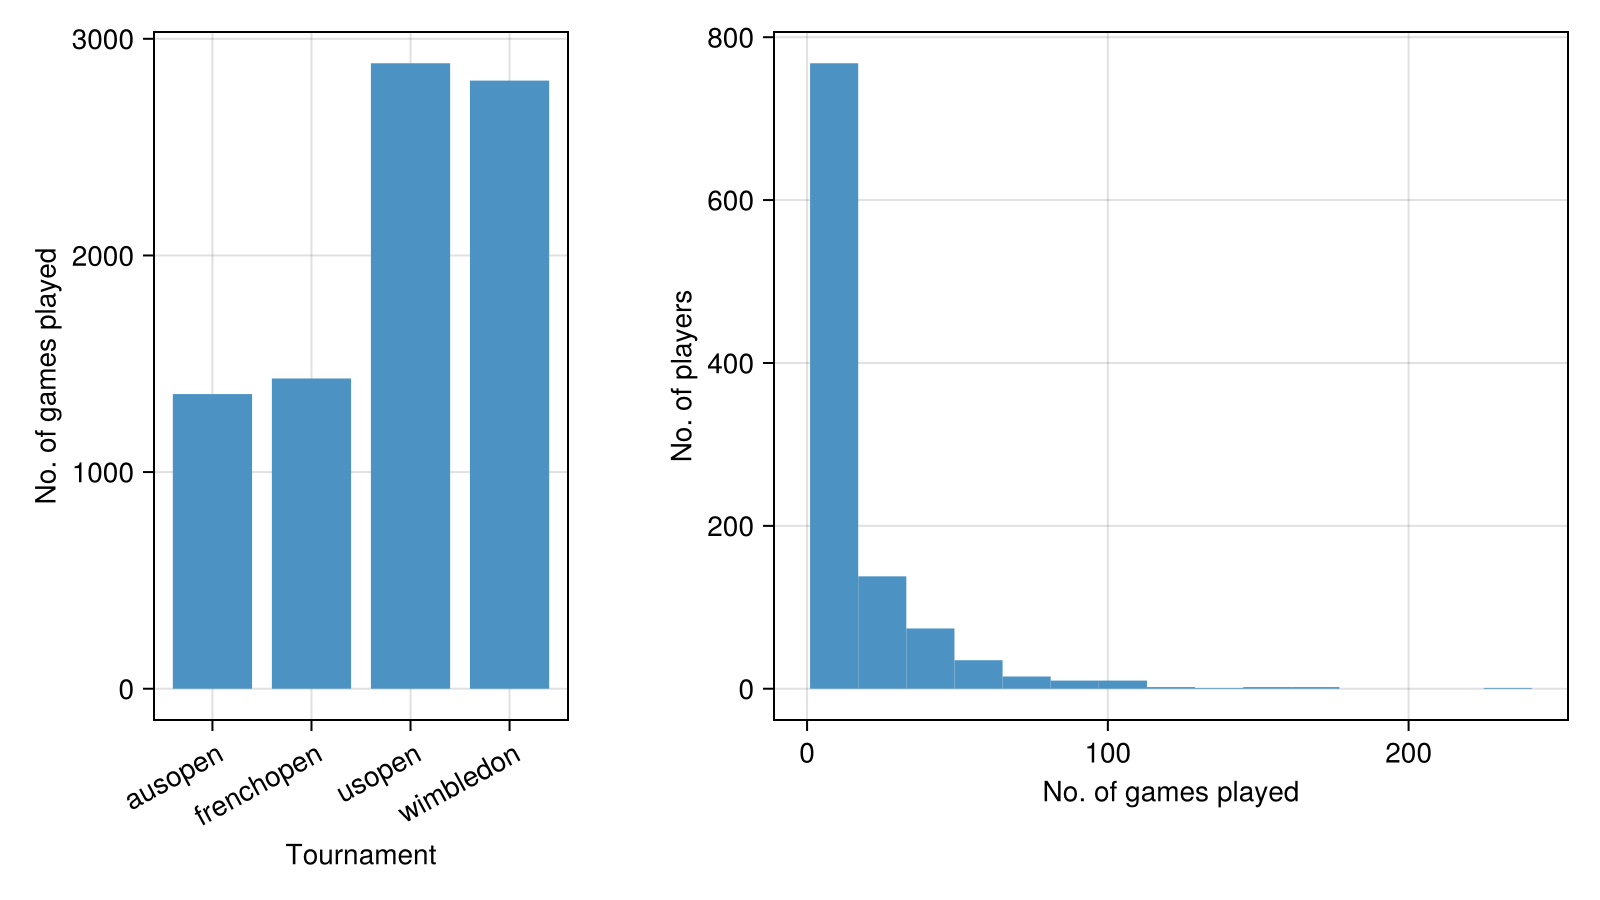

In [938]:
tmnts = categorical([d.Tmnt[1] for d in groupby(df, :match_id)])
tmnt_counts = countmap(tmnts)

f = Figure(size = (800, 450))

ax1 = Axis(f[1,1], 
    xticklabelrotation = 0.5,
    ylabel = "No. of games played",
    xlabel = "Tournament",
)
barplot!(
    levelcode.(tmnt_counts |> keys), 
    tmnt_counts |> values |> collect
)
ax1.xticks = (1:4, String.(levels(tmnts)))

ax2 = Axis(f[1,2],
    xlabel = "No. of games played",
    ylabel = "No. of players",
)
plt = hist!(values(player_games) |> collect)

colsize!(f.layout, 1, Aspect(1, 3/5))
colsize!(f.layout, 2, Auto(0.7))
colgap!(f.layout, 50)
resize_to_layout!(f)

f

In [773]:
CairoMakie.save(joinpath("figs", "tmnt_player_freq.png"), f)

## Histogram of win probabilities

In [970]:
gdf = groupby(df, [:match_id]);

In [971]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    gbp = g[g.BreakPoint,:]
    bpsw = mean(gbp.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    bpws[i] = bpsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, bpws);
# filter!((!) ∘ iszero, bps);

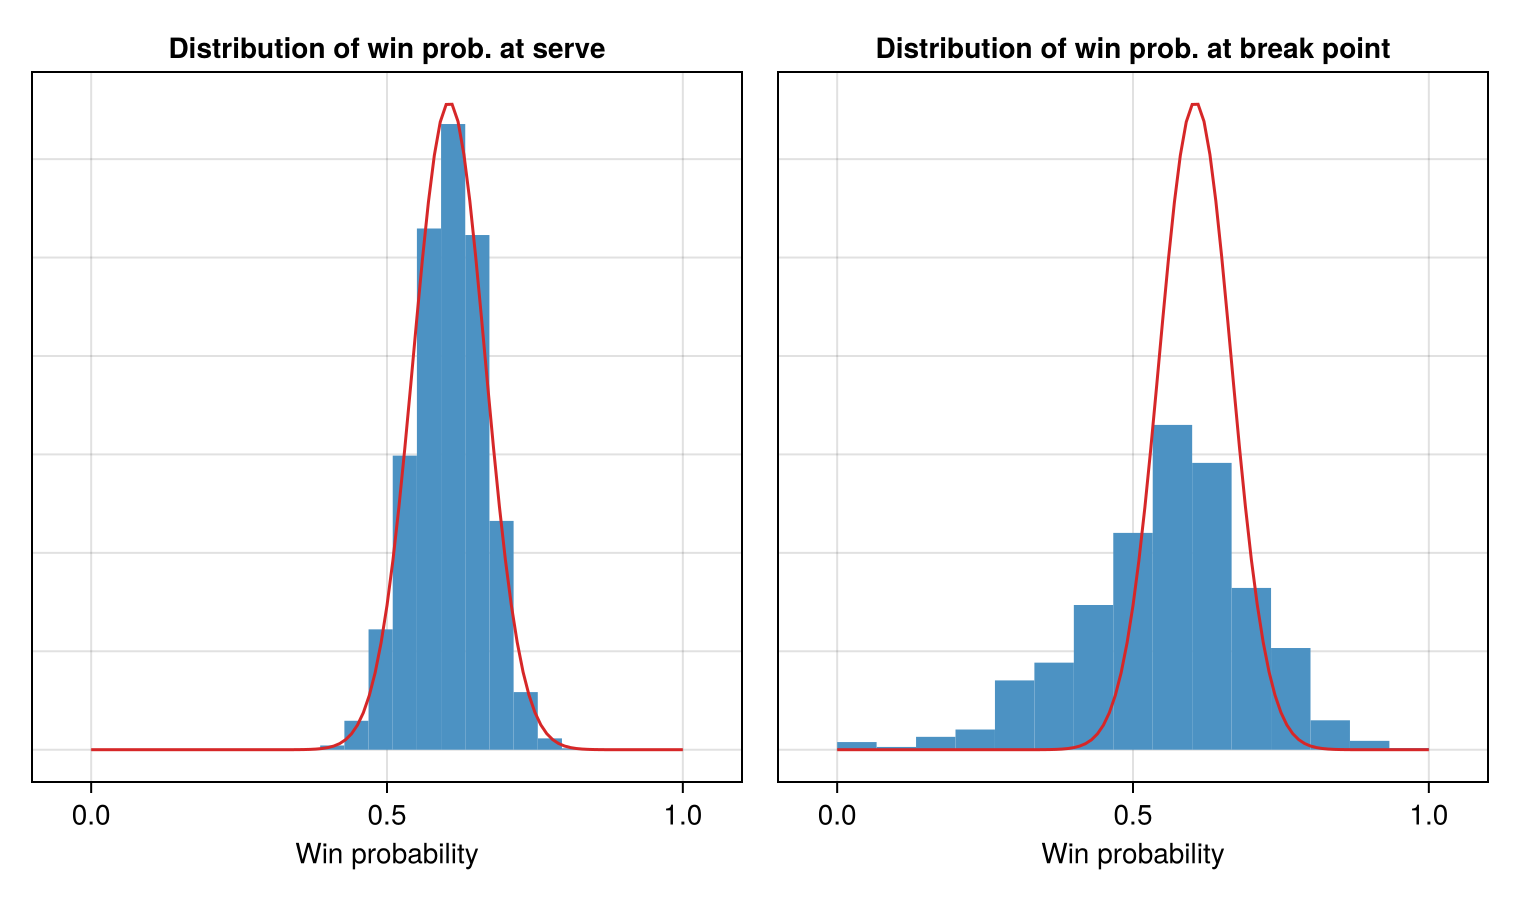

In [973]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at break point")
hist!(bpws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [522]:
CairoMakie.save("figs/win_prob_hists.png", f)

In [951]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    gbp = g[g.Tiebreaker,:]
    bpsw = mean(gbp.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    bpws[i] = bpsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, bpws);
# filter!((!) ∘ iszero, bps);

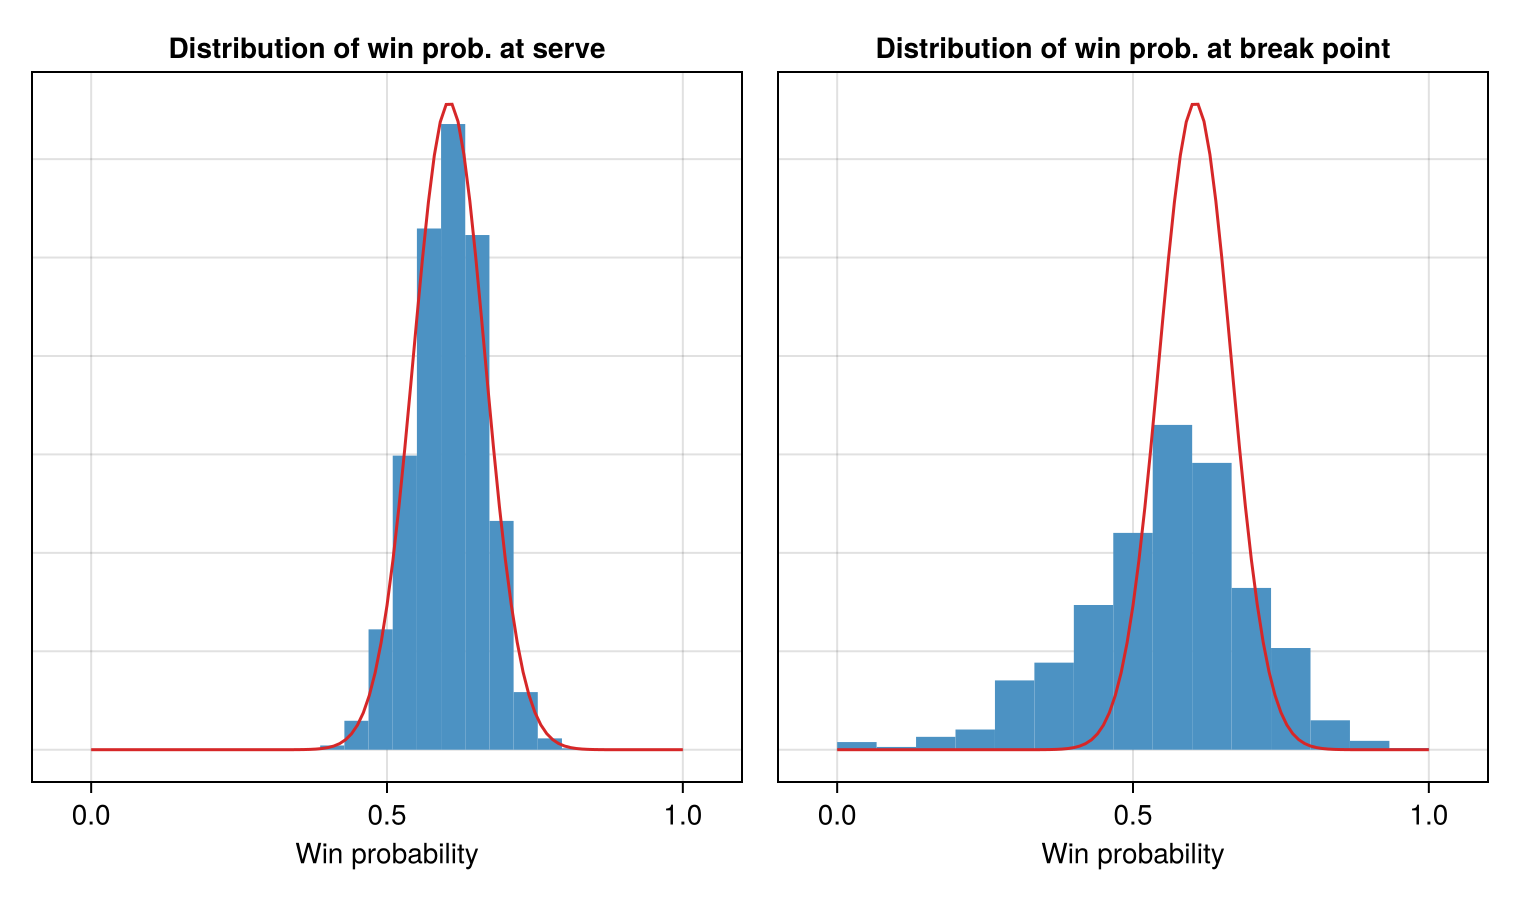

In [949]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at break point")
hist!(bpws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

### Goodness of fit test 

We test the probability that the break point serve win probability distribution is the same as the estimated normal distribution of the win serve win probability. We use the fact that, for $X_i \sim N(0,1)$,
$$
\sum_i^n (X_i - \bar{X})^2 \sim \chi_{n-1}^2 \quad \text{where}\quad 
\bar{X} = \frac{1}{n} \sum_i^n X_i.
$$

In [549]:
d = fit(Normal, pws)
T = sum((bpws .- mean(d)).^2) / var(d)
p_pws = 1 - cdf(Chisq(length(bpws)-1), T)

0.0

Then we also do a Kolmogorov-Smirnov test.

In [556]:
pvalue(ApproximateTwoSampleKSTest(pws, skipmissing(bpws) |> collect))

9.814543295768877e-304